Figure out why there's such a large degeneracy between sigma & dsigma/dM

In [28]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata
import importlib

In [4]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [8]:
params = eMCMC.build_param_data({'dsigdz':{'fit':False, 'value': 0}})

In [31]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [32]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [33]:
best_fit, samples, _ = my_UVLF.run_MCMC()

/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:153: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][nonfit_ids])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:154: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][nonfit_ids]
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [34]:
best_fit

[0.68, -0.04, -0.22, -0.01, 12.68, 0.33, -0.84, 0.05, 1.38, 0, -0.5]

/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:153: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(all(self.param_data['value'][nonfit_ids])):
/Users/eb35267/Desktop/code/home/escripts/eMCMC.py:154: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  insert_vals = self.param_data['value'][nonfit_ids]


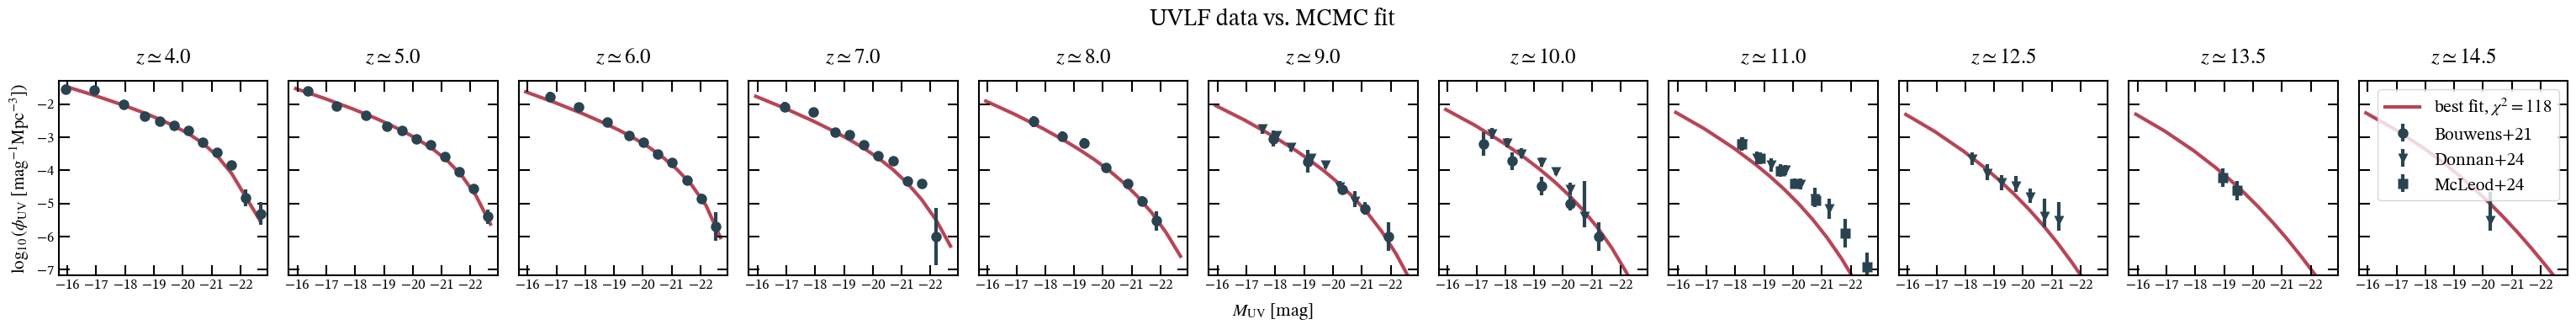

In [35]:
fit = eplots.plot_evolving_UVLF_fit(my_UVLF)

In [36]:
eMCMC.get_default_df()

,fit,value,start,lower,upper,label
alpha,True,0.6,0.6,0,4,$\alpha$
dalphadz,True,0,0.01,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-0.5,-1,0,$\beta$
dbetadz,True,0,0.01,-0.5,0.5,$d\beta/dz$
logMc,True,12,12,9,16,$\log(M_c)$
dlogMcdz,True,0,0.01,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-1,-1,1,$\log(\epsilon_0)$
dlogedz,True,0,0.01,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0.5,0,6,"$\sigma_{\rm{UV}, 10}$"
dsigdz,True,0,0.01,-0.5,0.5,$d\sigma_{\rm{UV}}/dz$


In [41]:
sig_samples, _, labels = my_UVLF.get_fit(exclude_unfit = False,
    excluded_params = ['alpha', 'dalphadz', 'beta', 'dbetadz', 'logMc', 'dlogMcdz', 'loge', 'dlogedz', 'dsigdz'])

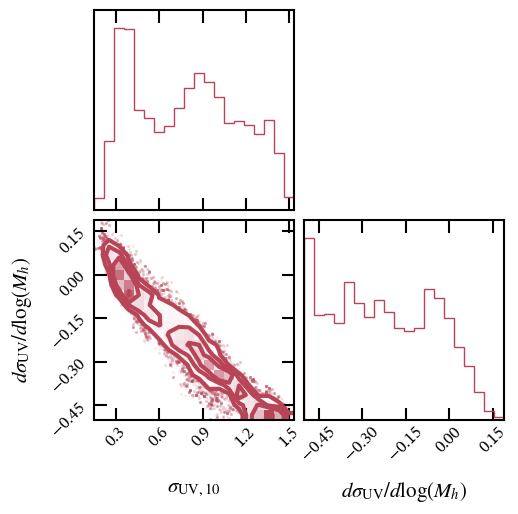

In [42]:
corner = eplots.plot_corner(sig_samples, labels)

Text(0.5, 1.0, '500 samples from MCMC chain, no $z$ dependence')

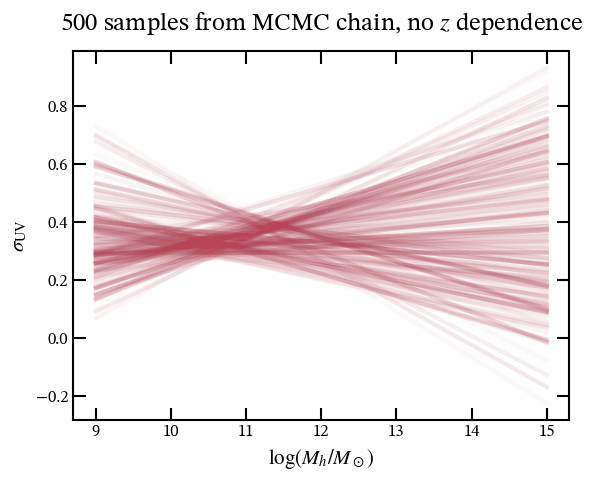

In [73]:
fig, ax = plt.subplots()
N = 500
Ms = np.linspace(9, 15, 3)

for sig0, dsigdM in zip(sig_samples[:N,0], sig_samples[:N,1]):
    ax.plot(Ms, (sig0 + dsigdM*(Ms-10)), color = eplots.red, linestyle = '-', alpha = 15/N)

ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$\log(M_h/M_\odot)$')
plt.title(f'{N} samples from MCMC chain, no $z$ dependence')

In [74]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/sig_Mh_space.png', bbox_inches='tight')

In [ ]:
def sig_vs_mass(sigma_samples, dsigdM_samples):
    fig, ax = plt.subplots()
    Ms = np.linspace(9, 15, 3)

    for fit, label in zip(sigma_fits, labels):
        sig, dsigdz, dsigdM = fit
        if dsigdz == 0:
            ax.plot(Ms, (sig + (dsigdM*(Ms-10))), label = f'{label}, all $z$', color = Plotting.orange, linestyle = '--')
        else:
            for z, color in zip(zs, gradient):
                ax.plot(Ms, (sig + (dsigdz*(z-8)))+ (dsigdM*(Ms-10)), label = f'{label}, $z={z}$', color = color, linestyle = '-')

    ax.set_xlabel(r'$\log_{10}(M_h/M_{\odot})$')
    ax.set_ylabel(r'$\sigma_{\rm{UV}}$')

    evolving_lines = Line2D([], [])
    const_lines = Line2D([0], [0], color=Plotting.orange, linestyle = '--')
    ax.legend([evolving_lines, const_lines], # Legend handles
              labels, handler_map={evolving_lines: eplots.HandlerStackedLine(gradient)})  # Applying custom handler only to Line2D

    return fig